Fit ARMA Model

In [41]:
arma_model = ARIMA(hr_series, order=(1,0,1)).fit()
print(arma_model.summary())

c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2270
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -7870.388
Date:                Sun, 01 Mar 2026   AIC                          15748.777
Time:                        21:45:08   BIC                          15771.687
Sample:                             0   HQIC                         15757.135
                               - 2270                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.3801      1.090     70.073      0.000      74.244      78.516
ar.L1          0.9763      0.005    198.318      0.000       0.967       0.986
ma.L1         -0.9047      0.011    -84.726      0.0

Comparison (AIC)

In [40]:
print("AR(1) AIC:", ar_model.aic)
print("MA(1) AIC:", ma_model.aic)
print("ARMA(1,1) AIC:", arma_model.aic)

AR(1) AIC: 15835.539128311526
MA(1) AIC: 15838.152660732281
ARMA(1,1) AIC: 15748.776963552953


Residual Diagnostics

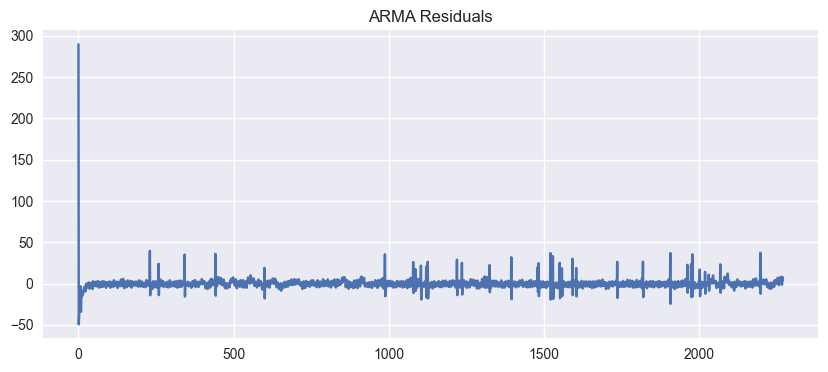

      lb_stat     lb_pvalue
10  48.533743  4.958059e-07


In [43]:
residuals = arma_model.resid

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("ARMA Residuals")
plt.show()

# Ljung-Box Test
ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(ljung_box)

Residual ACF

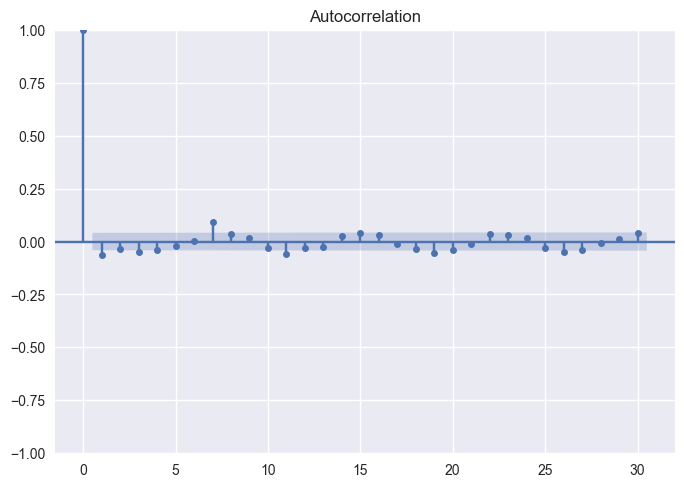

In [44]:
plot_acf(residuals, lags=30)
plt.show()

In [30]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# ADF test
adf_result = adfuller(hr_series)
print("ADF p-value:", adf_result[1])

# Nếu p-value > 0.05 → differencing
hr_diff = hr_series.diff().dropna()

ADF p-value: 2.312069060565629e-06


In [31]:
from statsmodels.tsa.arima.model import ARIMA

# AR(1) → order=(p=1, d=0, q=0)
model_ar = ARIMA(hr_series, order=(1, 0, 0))
result_ar = model_ar.fit()

print(result_ar.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2270
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -7914.770
Date:                Sun, 01 Mar 2026   AIC                          15835.539
Time:                        15:37:54   BIC                          15852.722
Sample:                             0   HQIC                         15841.808
                               - 2270                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.9490      0.311    244.167      0.000      75.339      76.559
ar.L1          0.1133      0.006     18.929      0.000       0.102       0.125
sigma2        62.5194      0.169    369.389      0.0

In [32]:
model_ar = ARIMA(hr_diff, order=(1, 0, 0))
result_ar = model_ar.fit()

c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided

In [33]:
# MA(1) → order=(0, 0, 1)
model_ma = ARIMA(hr_series, order=(0, 0, 1))
result_ma = model_ma.fit()

print(result_ma.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2270
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -7916.076
Date:                Sun, 01 Mar 2026   AIC                          15838.153
Time:                        15:38:21   BIC                          15855.335
Sample:                             0   HQIC                         15844.421
                               - 2270                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.9408      0.301    252.627      0.000      75.352      76.530
ma.L1          0.0893      0.008     11.816      0.000       0.074       0.104
sigma2        62.5936      0.167    374.592      0.0

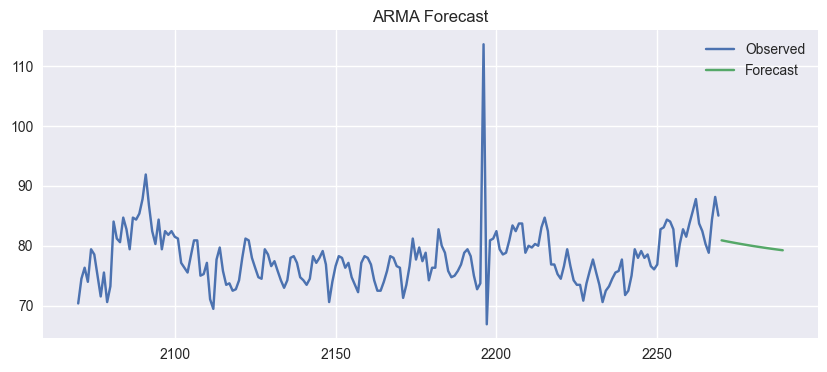

In [35]:
forecast = result_arma.forecast(steps=20)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(hr_series[-200:], label="Observed")
plt.plot(forecast.index, forecast, label="Forecast")
plt.legend()
plt.title("ARMA Forecast")
plt.show()